# Supplemental, find kappa for the chromatin

Code to compute the MG1 DG1 measure for finding the optimal kappa for the chromatin.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [444]:
from src.config import load_default_chrom_configs
from src.combined_chromatin_model import CombinedChromatinModel

config1, config2 = load_default_chrom_configs()

combined_model = CombinedChromatinModel(config1=config1, config2=config2)

from src.sgd import read_nondubious_genes_dataset
genes = read_nondubious_genes_dataset()
gene = genes[genes['gene'] == 'DSE3'].iloc[0]
mnase_span = gene.TSS-500, gene.TSS+501
chrom = gene.chr

# Load window to deconvolve
combined_model.load_mnase_span(chrom, mnase_span)
combined_model.setup_deconv_model(copy_correct=False)


Loading chromosome reads: 15
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 1000) to (16, 26, 100)
Loading chromosome reads: 15
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 1000) to (15, 26, 100)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr


In [524]:
combined_model.deconvolve(gamma=0.049, kappa=0.003, eta=0.264)

0/2600 - 00:00:00.003
500/2600 - 00:00:14.690
1000/2600 - 00:01:31.784
1500/2600 - 00:02:57.030
2000/2600 - 00:04:24.222
2500/2600 - 00:05:46.030
Completed - 00:05:53.968


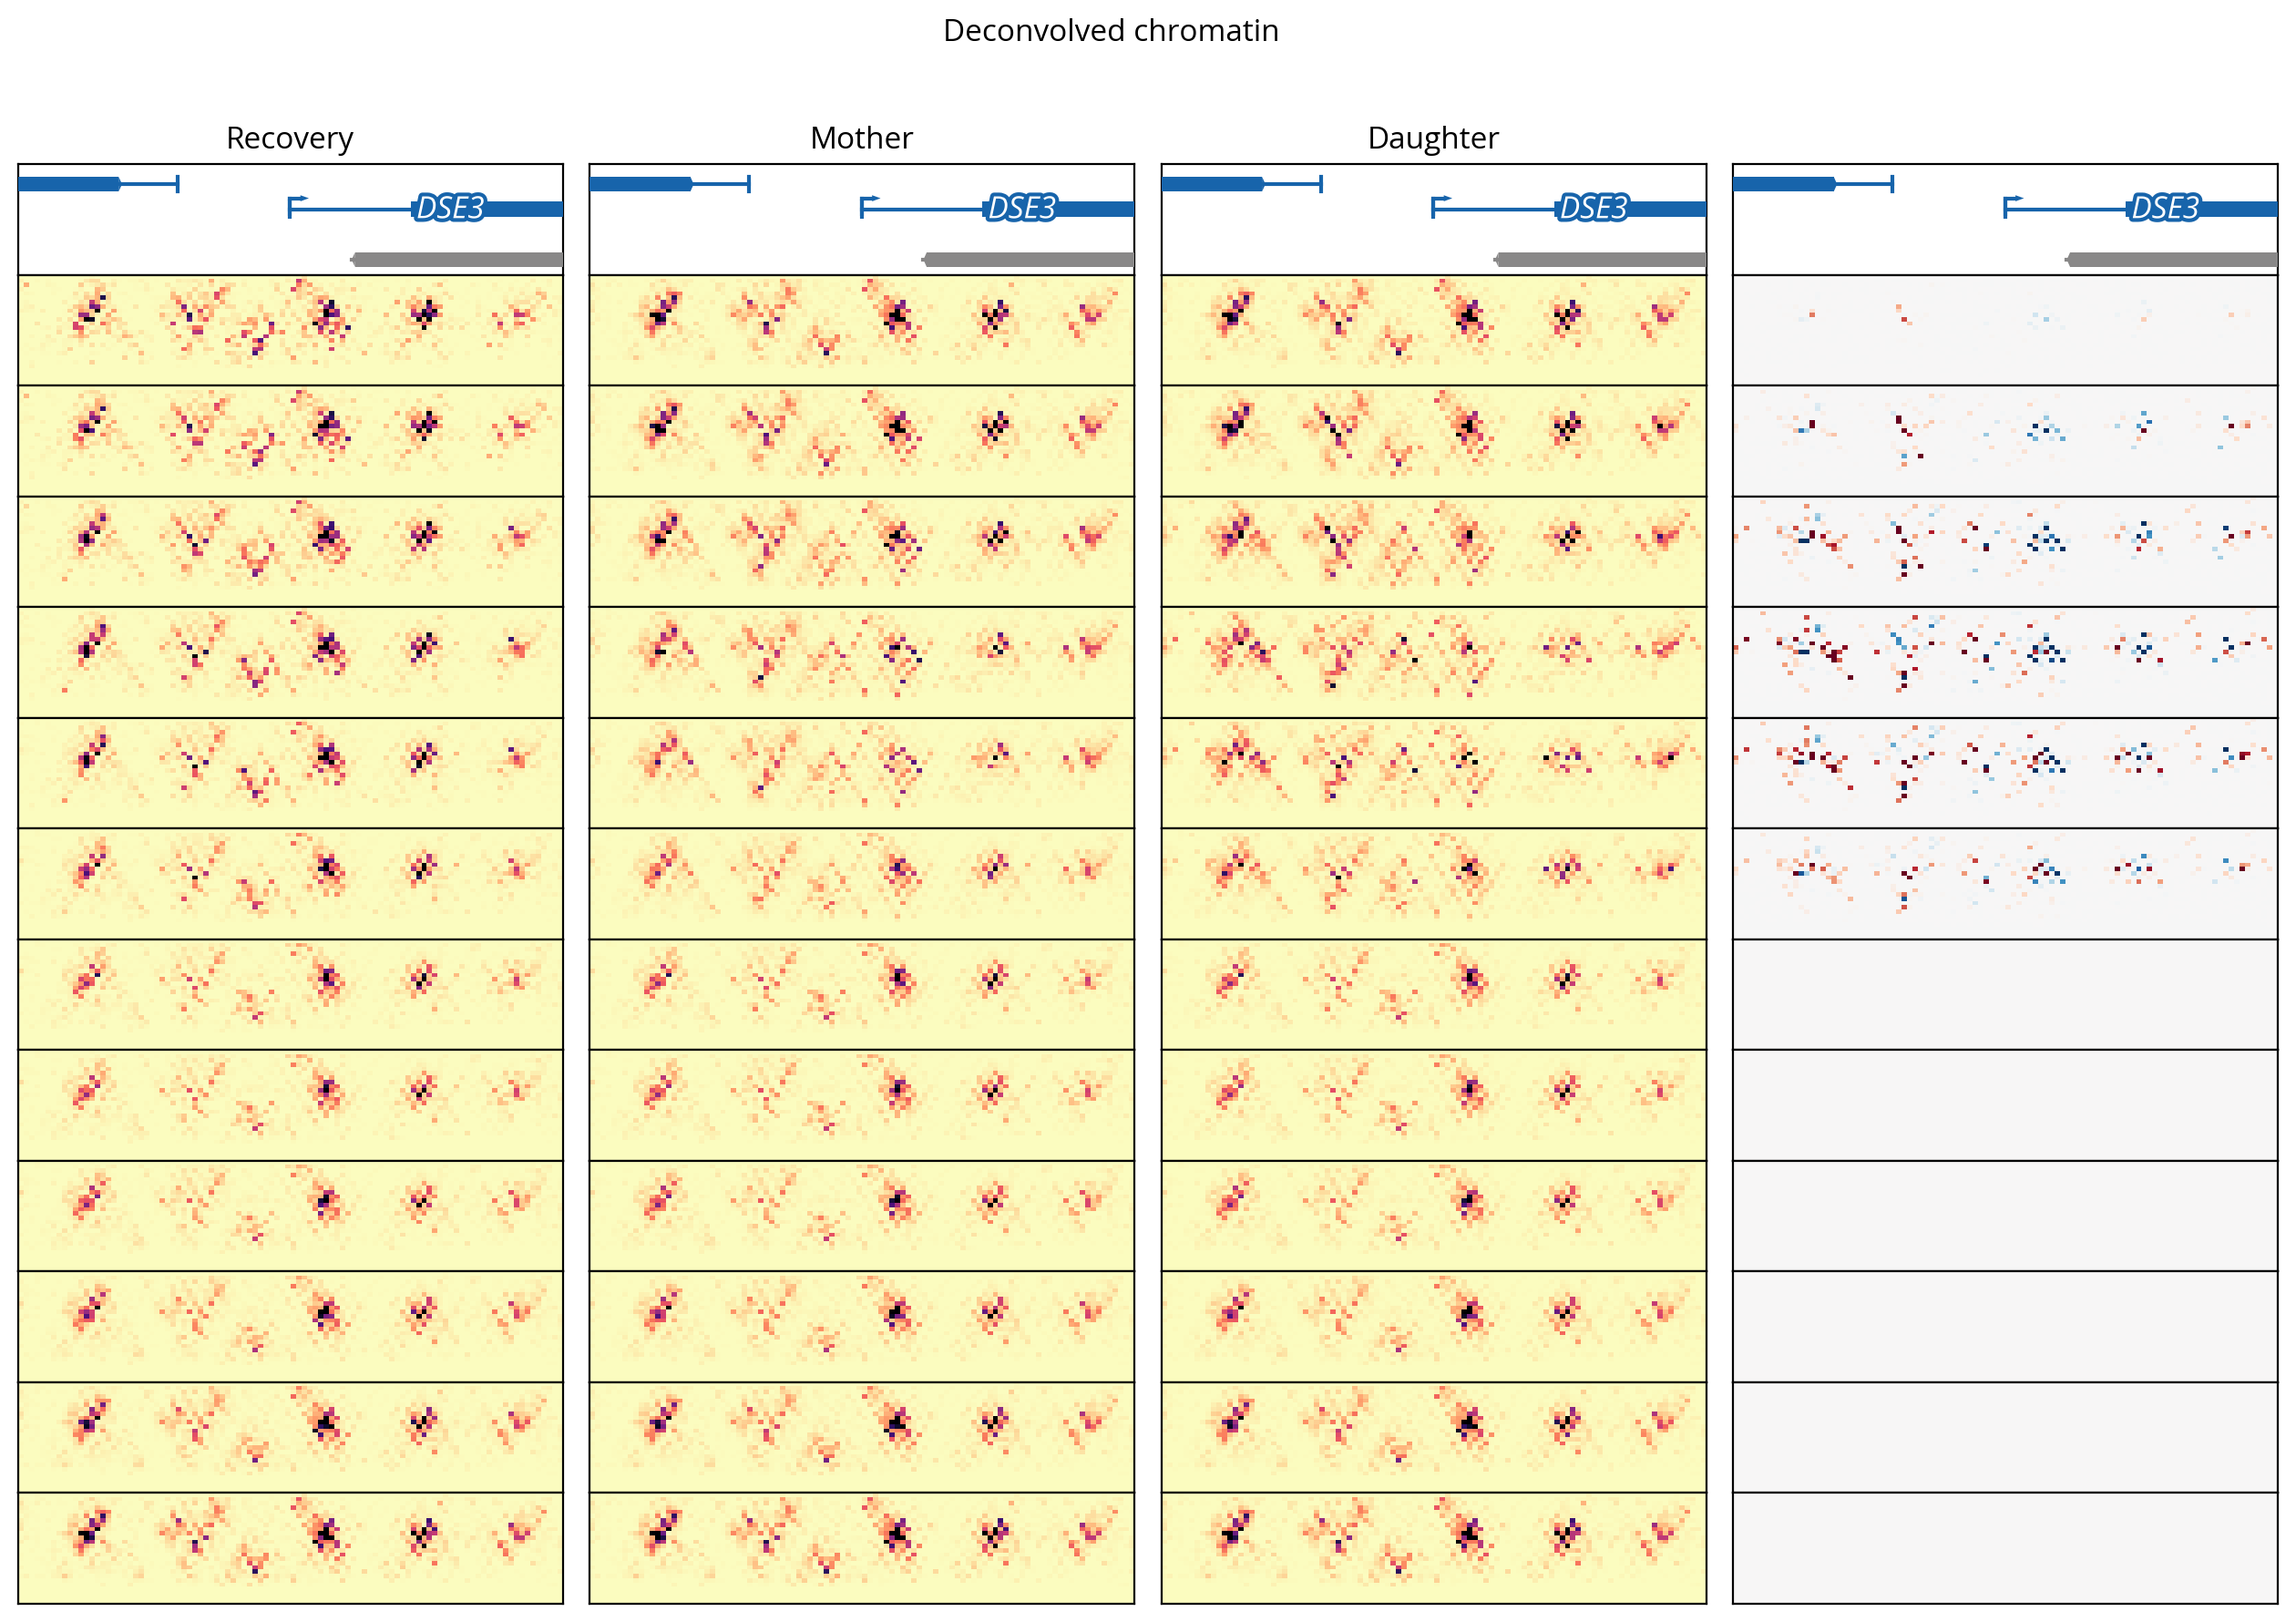

In [525]:
combined_model.plot_branches(figsize=(16, 10))

F_imgs shape: (257, 26, 100)
MG1 shape: (64, 26, 100)
DG1 shape: (64, 26, 100)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 100), DG1: (26, 100)
Total positions: 2600
Filtered positions: 1954
Filtered percentage: 75.2%
=== Step 2: Distribution Analysis ===
Mean difference: 0.142
Std difference: 1.783
Threshold range: [-1.641, 1.926]


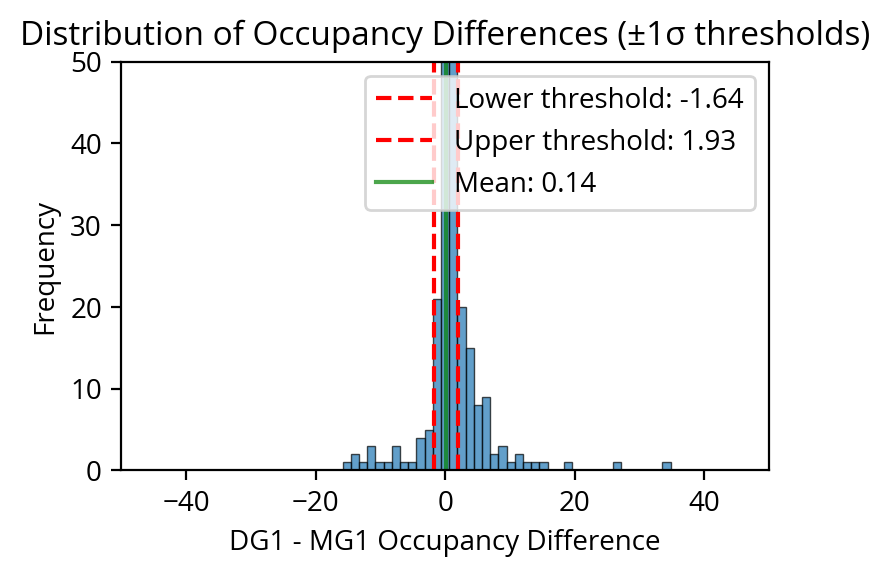

In [526]:
from src.dg1_mg1_island_analysis import ChromatinOccupancyIslandDetector

# Usage:
detector = ChromatinOccupancyIslandDetector(config1, config2, 
    combined_model.solver.F)
detector.step1_preprocess_data(min_occupancy=1e-3)
_ = detector.step2_analyze_distribution(std_multiplier=1, plot=True)

In [527]:
all_islands = detector.detect_all_island_types_strategy_b()

=== Strategy B: Island-First Classification ===
Step 1: Detecting significant total chromatin islands...
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 134
Detected 8 total occupancy islands
  Found 8 total chromatin islands
  Raw chromatin pixels: 134
  Significant island pixels: 111
  Filtering removed: 23 pixels
Step 2: Classifying pixels within significant islands...
  Using thresholds: lower=-1.641, upper=1.926
  Pixel classification within islands:
    Mother pixels: 20
    Daughter pixels: 24
    Unchanging pixels: 67
    Total classified: 111
  ✅ Verification passed: All island pixels classified exactly once
Step 3: Grouping classified pixels into islands...
  Island detection results:
    Mother islands: 3
    Daughter islands: 5
    Unchanging islands: 5
  Island coverage:
    Mother: 16/20 pixels (80.0% coverage, 4 lost to size filtering)
    Daughter: 24/24 pixels (100.0% coverage, 0 lost to size filtering)
    Unchanging: 67/67 pixe

In [528]:
# detector.plot_all_islands_overview()

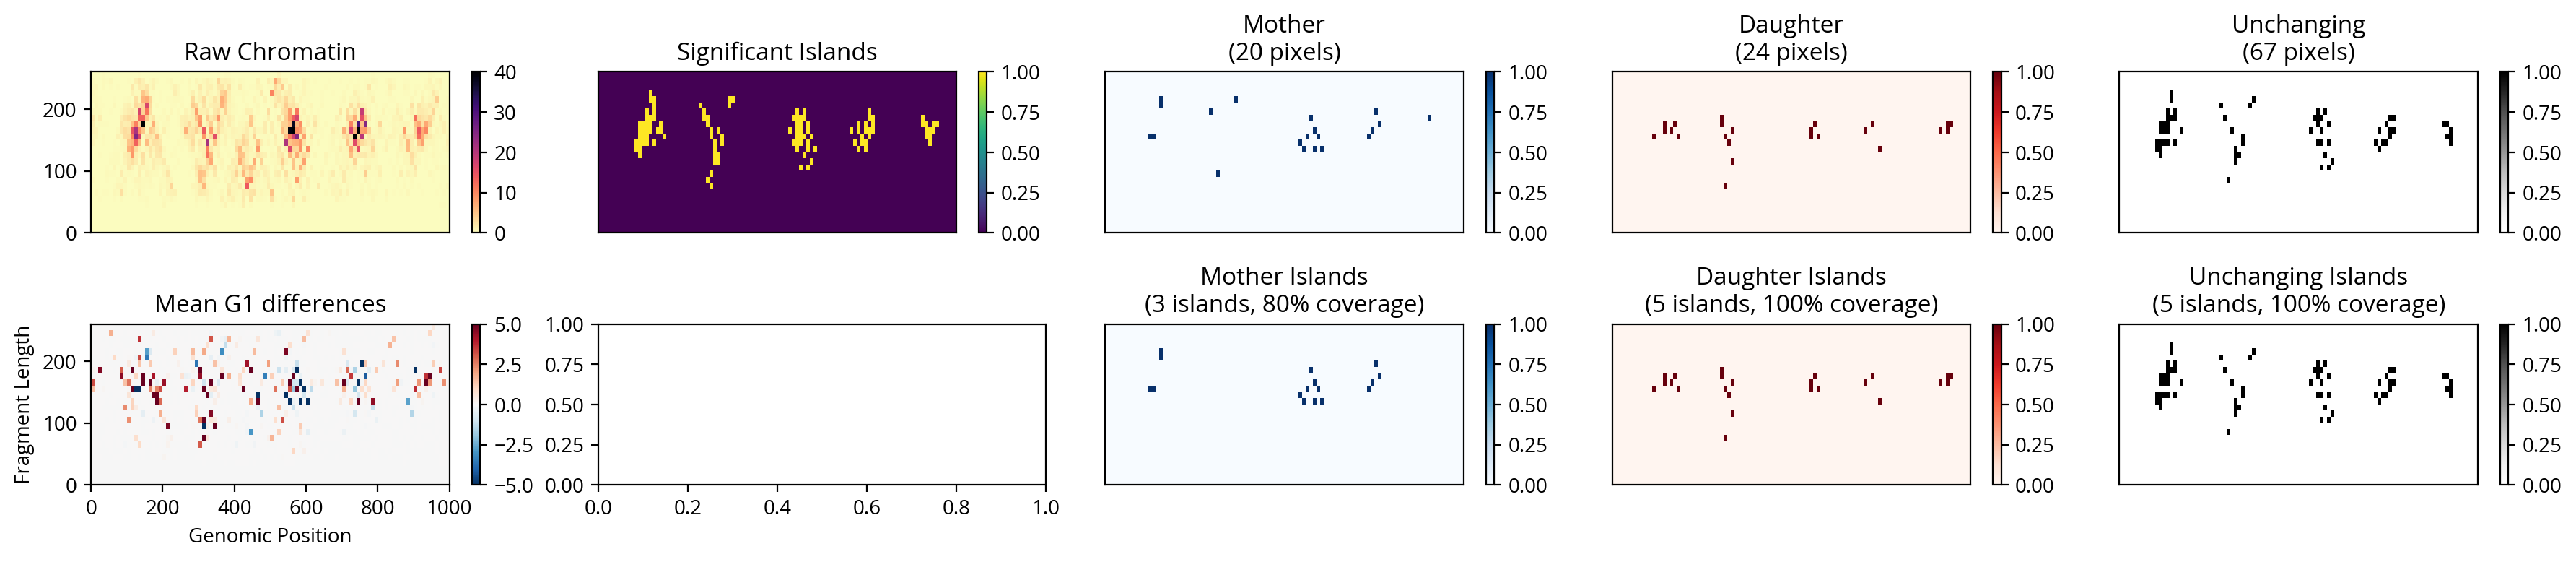

In [529]:
detector.plot_all_islands_strategy_b(show_filtering=True)

In [530]:
_ = detector.comprehensive_summary()


CHROMATIN LANDSCAPE COMPOSITION ANALYSIS

🧬 CHROMATIN BREAKDOWN:
   Total chromatin regions detected: 8 islands
   Genome coverage by chromatin: 4.3%

📊 CHROMATIN COMPOSITION (by island count):
   • Mother-specific:    23.1% (3 islands)
   • Daughter-specific:  38.5% (5 islands)
   • Unchanging:         38.5% (5 islands)

📊 CHROMATIN COMPOSITION (by pixel coverage):
   • Mother-specific:    15.0%
   • Daughter-specific:  22.4%
   • Unchanging:         62.6%

CHROMATIN LANDSCAPE COMPOSITION ANALYSIS
Classification method: strategy_b_island_first


In [425]:
dynamic_percent = detector.composition_stats['dynamics']['dynamic_percent']
print(f"{dynamic_percent:.2f}% "
        "of the chromatin is mother or daughter-specific")

6.67% of the chromatin is mother or daughter-specific


In [ ]:
optimizer = ChromatinKappaOptimizer(output_dir, save_dir, gamma=0.07)
optimizer.set_chromosome_span(1, (45000, 46000))

# This now runs the focused search instead of broad sweep
optimal_kappa, results_df = optimizer.find_optimal_kappa_focused(
    kappa_min=1e-5, 
    kappa_max=1.0,
    verbose=True,
    save_results=True
)

In [383]:
from src.chromatin_find_kappa import ChromatinKappaOptimizer

# Initialize for a specific gamma value
optimizer = ChromatinKappaOptimizer(
    output_dir="output/draft3_run/",
    save_dir="output/draft3_run/find_kappa_chromatin",
    gamma=0.07
)

# Run analysis on different genomic windows
windows = [(1, (45000, 45200)), (2, (100000, 100200))]

for chrom, span in windows:
    optimizer.set_chromosome_span(chrom, span)
    results = optimizer.find_optimal_kappa_focused(
    kappa_min=1e-5, 
    kappa_max=1.0,
    verbose=True,
    save_results=True)


Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 199) to (16, 26, 20)
Loading chromosome reads: 1
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 199) to (15, 26, 20)
Loading copy correction N, Fr, B from output/draft3_run/
Disabling copy correction, using identity functions for N, b, and fr
Running focused kappa optimization on chr1:45000-45200
Using gamma=0.07
Step 1: Calculating dynamic 

500/520 - 00:00:59.579
Completed - 00:01:00.226
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: 0.022
Std difference: 0.364
Threshold range: [-0.342, 0.386]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 4
Negative outlier pixels: 3
Detected 1 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 7
Remaining pixels after M/D subtraction: 29
Detected 2 unchanging islands
		κ: 0.00782242	dynamics: 19.444%	rn: 51.5007	sn: 26.6098
0/520 - 00:00:00.000
500/520 - 00:01:00.949
Completed - 00:01:01.592
F_imgs shape: (257, 

500/520 - 00:00:58.137
Completed - 00:00:58.753
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: 0.137
Std difference: 1.810
Threshold range: [-1.673, 1.947]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 13
Negative outlier pixels: 6
Detected 1 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 16
Remaining pixels after M/D subtraction: 23
Detected 2 unchanging islands
		κ: 0.0011544	dynamics: 41.026%	rn: 51.4372	sn: 26.7589
0/520 - 00:00:00.000
500/520 - 00:00:58.396
Completed - 00:00:59.009
F_imgs shape: (257,

500/520 - 00:01:01.204
Completed - 00:01:01.847
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: -0.000
Std difference: 0.000
Threshold range: [-0.100, 0.100]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 0
Negative outlier pixels: 0
Detected 0 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 0
Remaining pixels after M/D subtraction: 34
Detected 2 unchanging islands
		κ: 0.0323716	dynamics: 0.000%	rn: 51.5307	sn: 26.4653
0/520 - 00:00:00.000
500/520 - 00:01:01.346
Completed - 00:01:02.021
F_imgs shape: (257, 2

500/520 - 00:00:59.649
Completed - 00:01:00.269
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 314
Filtered percentage: 60.4%
=== Step 2: Distribution Analysis ===
Mean difference: 0.003
Std difference: 0.093
Threshold range: [-0.097, 0.103]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 34
Detected 2 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 2
Negative outlier pixels: 3
Detected 0 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 3
Remaining pixels after M/D subtraction: 32
Detected 2 unchanging islands
		κ: 0.0110949	dynamics: 8.571%	rn: 51.5129	sn: 26.6102
0/520 - 00:00:00.000
500/520 - 00:00:59.422
Completed - 00:01:00.049
F_imgs shape: (257, 26

...

500/520 - 00:01:05.793
Completed - 00:01:07.028
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: 0.020
Std difference: 0.784
Threshold range: [-0.764, 0.805]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 5
Negative outlier pixels: 2
Detected 1 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 3
Remaining pixels after M/D subtraction: 23
Detected 1 unchanging islands
		κ: 0.00782242	dynamics: 11.538%	rn: 41.3872	sn: 26.4840
0/520 - 00:00:00.000
500/520 - 00:01:05.095
Completed - 00:01:06.333
F_imgs shape: (257, 

500/520 - 00:01:05.167
Completed - 00:01:06.402
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: 0.068
Std difference: 1.215
Threshold range: [-1.147, 1.283]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 11
Negative outlier pixels: 8
Detected 1 positive islands
Detected 1 negative islands
Mother/Daughter pixels: 18
Remaining pixels after M/D subtraction: 11
Detected 1 unchanging islands
		κ: 0.00139854	dynamics: 62.069%	rn: 41.3187	sn: 26.9862
0/520 - 00:00:00.000
500/520 - 00:01:04.531
Completed - 00:01:05.789
F_imgs shape: (257

500/520 - 00:01:05.278
Completed - 00:01:06.545
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: -0.000
Std difference: 0.000
Threshold range: [-0.100, 0.100]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 0
Negative outlier pixels: 0
Detected 0 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 0
Remaining pixels after M/D subtraction: 25
Detected 1 unchanging islands
		κ: 0.0326164	dynamics: 0.000%	rn: 41.4153	sn: 26.7924
0/520 - 00:00:00.000
500/520 - 00:01:05.780
Completed - 00:01:07.019
F_imgs shape: (257, 2

500/520 - 00:01:04.780
Completed - 00:01:06.018
F_imgs shape: (257, 26, 20)
MG1 shape: (64, 26, 20)
DG1 shape: (64, 26, 20)
=== Step 1: Data Preprocessing ===
After time averaging - MG1: (26, 20), DG1: (26, 20)
Total positions: 520
Filtered positions: 359
Filtered percentage: 69.0%
=== Step 2: Distribution Analysis ===
Mean difference: -0.011
Std difference: 0.589
Threshold range: [-0.600, 0.579]
=== Step 4: Comprehensive Island Detection ===
=== Step 4a: Total Occupancy Islands ===
Occupancy threshold: 5
Pixels above threshold: 25
Detected 1 total occupancy islands
Running step3 to detect std islands...
=== Step 3: Island Detection ===
Positive outlier pixels: 4
Negative outlier pixels: 2
Detected 1 positive islands
Detected 0 negative islands
Mother/Daughter pixels: 3
Remaining pixels after M/D subtraction: 23
Detected 1 unchanging islands
		κ: 0.00963858	dynamics: 11.538%	rn: 41.3951	sn: 26.5653
0/520 - 00:00:00.000
500/520 - 00:01:04.382
Completed - 00:01:05.613
F_imgs shape: (257,

KeyboardInterrupt: 

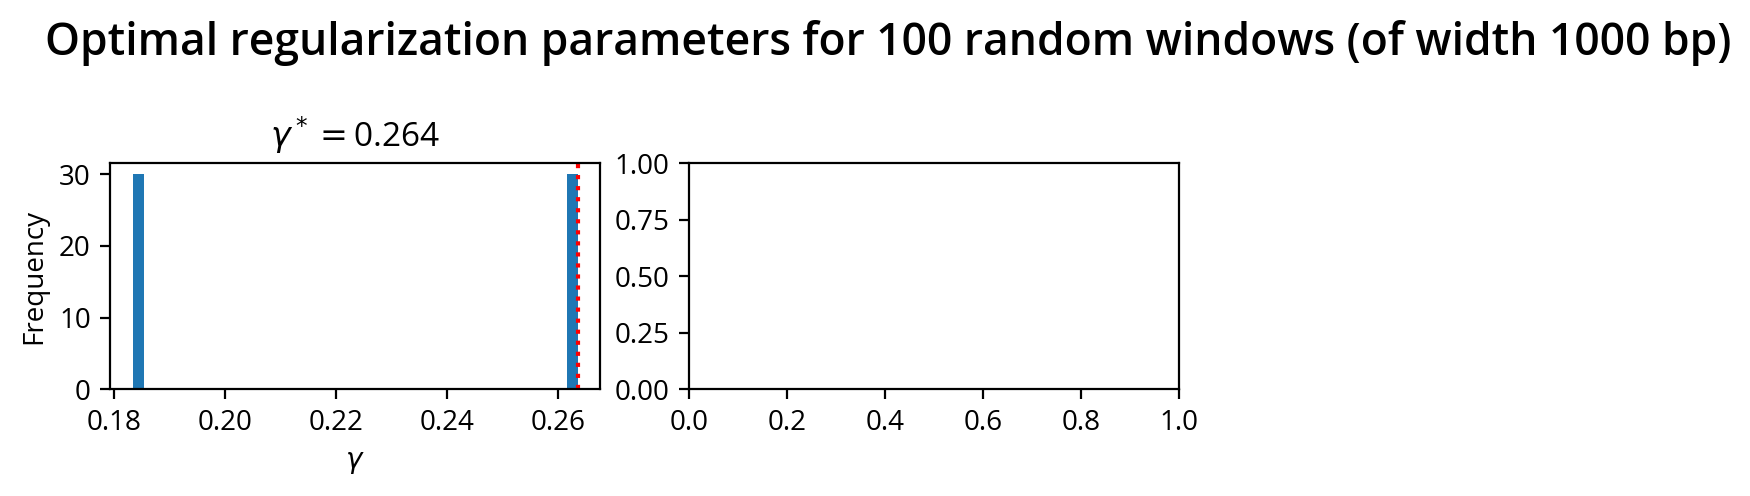

In [583]:
from pipeline.run_pipeline import run_gamma_kappa_eta_summary

run_gamma_kappa_eta_summary('output/draft4_run/')


In [555]:
gamma = np.array([0.50005,0.250075,0.125087,0.062593,0.031346,0.015723,0.007911,0.004005,0.005958,0.004982,0.005470,0.00571,])
sn = np.array([10.2712,14.8766,22.9121,36.8833,57.4021,93.6880,147.9343,223.0159,176.5083,196.4477,185.7278,181.2355])
mean_sn = np.array([8.4797, 10.2809, 13.2683, 16.1484, 20.9943, 30.7209, 50.8430, 82.9916, 63.5605, 72.1639, 68.1448, 65.9272])
rn = np.array([47.172,45.562,44.146,42.908,41.998,41.217,40.613,40.189,40.417,40.308,40.364,40])

[0.031346 0.005958 0.00571 ]


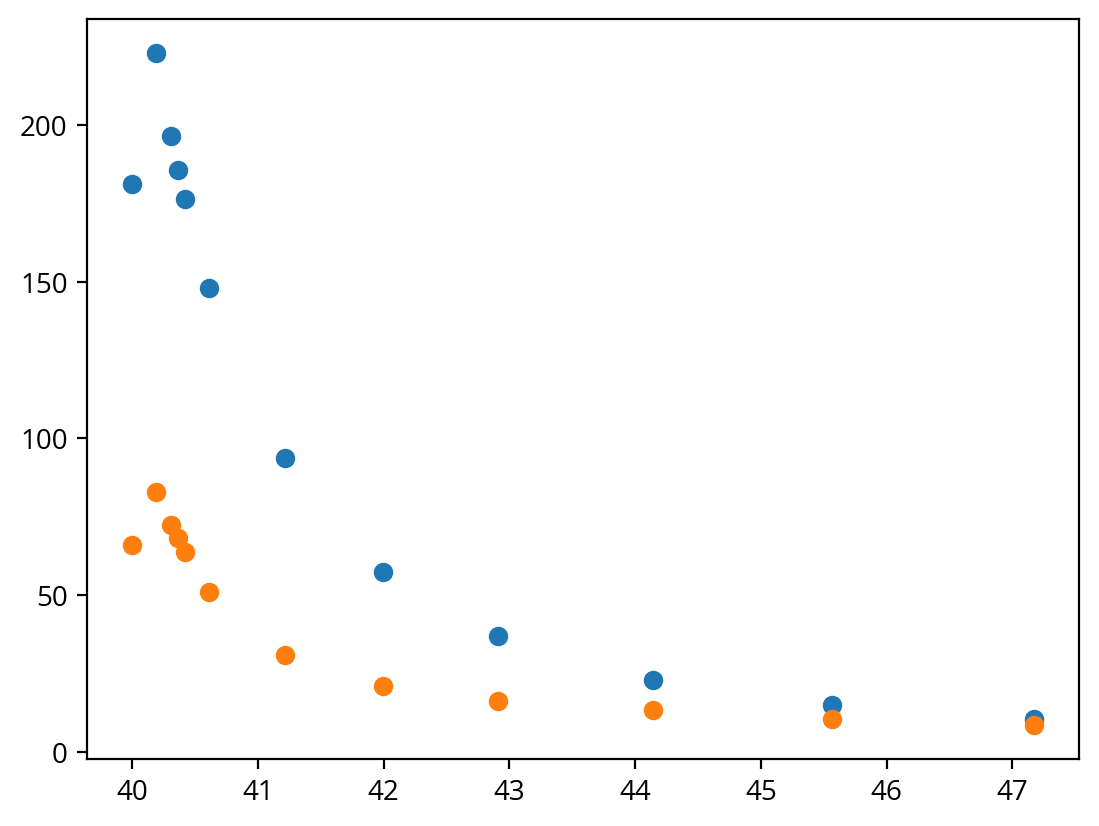

In [570]:
from kneed import KneeLocator
kn = KneeLocator(rn, sn, curve='convex', direction='decreasing')
optima_kn_indices = kn.maxima_indices

plt.scatter(rn, sn)

kn = KneeLocator(rn, mean_sn, curve='convex', direction='decreasing')
optima_kn_indices = kn.maxima_indices

plt.scatter(rn, mean_sn)
print(gamma[optima_kn_indices])

In [572]:
res_df = pd.DataFrame({
    'gamma': gamma,
    'rn': rn,
    'sn': sn
})

res_df

,gamma,rn,sn
0,0.500050,47.172,10.2712
1,0.250075,45.562,14.8766
2,0.125087,44.146,22.9121
3,0.062593,42.908,36.8833
4,0.031346,41.998,57.4021
5,0.015723,41.217,93.6880
6,0.007911,40.613,147.9343
7,0.004005,40.189,223.0159
8,0.005958,40.417,176.5083
9,0.004982,40.308,196.4477
